# Flash-Attn Topic Modeling of arXiv Papers (End-to-End Example)

This notebook loads a subset of arXiv metadata (titles + abstracts), builds transformer embeddings, clusters them into topics, labels topics with TF-IDF keywords, and visualizes the topic map (UMAP/TSNE).

**Pipeline**
1. Load + preprocess JSONL (titles, abstracts → `text`)
2. Encode texts with a transformer (auto-uses CUDA/MPS if available; Flash-Attn if present)
3. K-Means clustering to get topics
4. Topic labeling via class-based TF-IDF
5. 2D projection (UMAP/TSNE) for visualization

See the API notebook for function-level documentation: `flash_attn.API.ipynb`.


## Global setup (seeds, logging, device, env flags)
Sets deterministic seeds, quiets tokenizer warnings/telemetry, configures basic logging, and detects the compute device (cuda/mps/cpu) for consistent, repeatable runs.
Contains: %load_ext, seeds, env vars, logger, device.

In [3]:
# --- Global setup: seeds, logging, env flags ---
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os, random, logging, warnings, numpy as np
import torch

# Stable runs
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# Quiet down tokenizers + speed issues
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ.setdefault("HF_HUB_DISABLE_TELEMETRY", "1")

# Basic logging
logging.basicConfig(level=logging.INFO, format="%(levelname)s:%(name)s:%(message)s")
logger = logging.getLogger("flash_attn_demo")

# Device
device = ("cuda" if torch.cuda.is_available()
          else "mps" if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available()
          else "cpu")
logger.info(f"Using device: {device}")
warnings.filterwarnings("ignore")


INFO:flash_attn_demo:Using device: cpu


## Imports, paths, and small knobs
Imports project helpers and defines all paths + small configuration constants (input JSONL, cleaned Parquet, doc limits, min abstract length, and K).
Contains: from flash_attn_utils import …, DATA_PATH, CLEAN_PATH, MAX_DOCS, MIN_ABS_LEN, K.

In [4]:
from pathlib import Path
from flash_attn_utils import (
    load_and_preprocess_arxiv,
    load_encoder, encode_texts,
    cluster_kmeans, describe_topics_tfidf,
    reduce_2d,
)

# Paths & small knobs
DATA_PATH   = Path("/data/UmdTask39_Fall2025_flash_attn_Topic_Modeling_of_Scientific_Papers/data/arxiv-metadata-oai-snapshot.json")
CLEAN_PATH  = Path("/data/UmdTask39_Fall2025_flash_attn_Topic_Modeling_of_Scientific_Papers/data/clean_subset.parquet")

MAX_DOCS    = 2000   # start small on CPU; you can try 5000–10000 later
MIN_ABS_LEN = 50     # filter very short abstracts
K            = 10     # initial number of clusters


## Load, sanity-check, and persist a cleaned subset
Streams arXiv JSONL, keeps only useful fields (id, title, abstract, categories, text), filters very short abstracts, prints quick stats, and saves the cleaned slice to Parquet/CSV for reuse.
Contains: load_and_preprocess_arxiv(...), duplicate/category snapshot, df.to_parquet(...), CSV fallback.

In [5]:
# Load, quick sanity checks, and persist cleaned subset

import sys, subprocess
import pandas as pd

# 3.1 Load & minimally clean
df = load_and_preprocess_arxiv(
    str(DATA_PATH),
    max_docs=MAX_DOCS,
    min_abstract_len=MIN_ABS_LEN,
)
print(f"Loaded {len(df):,} records")
display(df.head(2))

# 3.2 Quick sanity checks (optional but useful)
dup_ids = df["id"].duplicated().sum() if "id" in df.columns else 0
print(f"Duplicate arXiv IDs: {dup_ids}")
if "categories" in df.columns:
    print("\nCategory snapshot (top 10):")
    display(df["categories"].str.split().explode().value_counts().head(10))

# 3.3 Save cleaned subset (Parquet preferred; fallback to CSV if engine missing)
try:
    df.to_parquet(CLEAN_PATH, index=False)
    print(f"\nSaved Parquet: {CLEAN_PATH}")
except Exception as e:
    # Install a PyArrow version that works on Python 3.8 in this container
    print(f"Parquet save failed ({e}); installing pyarrow and retrying...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--no-cache-dir", "pyarrow==12.0.1"])
    df.to_parquet(CLEAN_PATH, index=False)
    print(f"Saved Parquet after install: {CLEAN_PATH}")

# Optional human-readable copy for quick peeks
csv_path = CLEAN_PATH.with_suffix(".csv")
df.to_csv(csv_path, index=False)
print(f"Also saved CSV: {csv_path}")


Loaded 1,995 records


,id,title,abstract,categories,text
0,0704.0001,Calculation of prompt diphoton production cros...,A fully differential calculation in perturbati...,hep-ph,calculation of prompt diphoton production cros...
1,0704.0002,Sparsity-certifying Graph Decompositions,"We describe a new algorithm, the $(k,\ell)$-pe...",math.CO cs.CG,sparsity-certifying graph decompositions. we d...


Duplicate arXiv IDs: 0

Category snapshot (top 10):


categories
astro-ph              444
hep-th                179
hep-ph                176
quant-ph              133
cond-mat.mtrl-sci     105
gr-qc                 104
cond-mat.str-el       102
cond-mat.stat-mech     99
cond-mat.mes-hall      81
math.MP                71
Name: count, dtype: int64


Saved Parquet: /data/UmdTask39_Fall2025_flash_attn_Topic_Modeling_of_Scientific_Papers/data/clean_subset.parquet
Also saved CSV: /data/UmdTask39_Fall2025_flash_attn_Topic_Modeling_of_Scientific_Papers/data/clean_subset.csv


## Encode texts and cache embeddings (with timing)
Loads a compact sentence-transformer, encodes df["text"] into embeddings with a timing measurement (docs/sec), and saves the embedding matrix (.npy) so you don’t re-compute later.
Contains: load_encoder(...), encode_texts(...), throughput print, np.save(...).

In [6]:
import time
from transformers import PreTrainedTokenizerBase, PreTrainedModel
import numpy as np

# 4.1 Load encoder (robust to return order)
ret = load_encoder("sentence-transformers/all-MiniLM-L6-v2")
if len(ret) != 3:
    raise RuntimeError("load_encoder must return 3 items (tokenizer/model/device).")
a, b, device2 = ret
if isinstance(a, PreTrainedTokenizerBase) and isinstance(b, PreTrainedModel):
    tok, mdl = a, b
elif isinstance(b, PreTrainedTokenizerBase) and isinstance(a, PreTrainedModel):
    mdl, tok = a, b
else:
    raise RuntimeError("Could not determine tokenizer/model order from load_encoder return.")

# 4.2 Encode titles+abstracts
texts = df["text"].tolist()
t0 = time.time()
emb = encode_texts(
    texts,
    tok,
    mdl,
    device2,          # device from load_encoder
    batch_size=64,
    max_length=256
)
dt = time.time() - t0
print(emb.shape, f"{len(texts)/max(dt,1):.1f} docs/sec", f"{dt:.1f}s total")

# 4.3 Save embeddings for reuse
EMB_PATH = CLEAN_PATH.with_name("clean_subset_embeddings.npy")
np.save(EMB_PATH, emb)
print(f"Saved embeddings: {EMB_PATH}")

INFO:flash_attn_utils:Loaded model sentence-transformers/all-MiniLM-L6-v2 on cpu
Encoding: 100%|██████████| 32/32 [01:06<00:00,  2.08s/it]

(1995, 384) 30.0 docs/sec 66.5s total
Saved embeddings: /data/UmdTask39_Fall2025_flash_attn_Topic_Modeling_of_Scientific_Papers/data/clean_subset_embeddings.npy


## Cluster embeddings and extract topic keywords
Runs K-Means to assign topic labels, then uses TF-IDF (English stopwords + bigrams) to get top terms per cluster; also computes a quick clustering quality score (silhouette).
Contains: cluster_kmeans(...), TfidfVectorizer(...), top terms per cluster, silhouette_score(...).

In [7]:
from sklearn.metrics import silhouette_score
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# 5.1 K-Means clustering
labels, km = cluster_kmeans(emb, k=K)
df["cluster"] = labels
print(df["cluster"].value_counts().sort_index())

# 5.2 Topic keywords with stopwords removed + bigrams
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_df=0.8,
    min_df=5,
    ngram_range=(1, 2),
    norm="l2",
)
X = vectorizer.fit_transform(df["text"].tolist())
terms = np.array(vectorizer.get_feature_names_out())

def top_terms_for_cluster(X, labels, c, top_k=10, ban=None):
    idx = np.where(labels == c)[0]
    if len(idx) == 0:
        return []
    sub = X[idx]
    scores = np.asarray(sub.mean(axis=0)).ravel()
    order = np.argsort(scores)[::-1]
    ordered = terms[order]
    if ban:
        ordered = [t for t in ordered if t not in ban and not t.isdigit()]
    return ordered[:top_k]

domain_stop = {
    "result","results","paper","approach","method","methods","model","models",
    "data","dataset","study","analysis","problem","problems"
}

topics = {}
for c in sorted(set(labels)):
    topics[c] = list(top_terms_for_cluster(X, labels, c, top_k=10, ban=domain_stop))
    print(f"Topic {c:02d}: " + ", ".join(topics[c][:8]))

# 5.3 Quick quality metric
sil = silhouette_score(emb, labels)
print("Silhouette:", sil)


cluster
0      3
1    258
2    163
3    130
4    211
5    279
6    303
7    211
8    246
9    191
Name: count, dtype: int64
Topic 00: differential, operations, counting, order, higher order, higher, combinatorial, space
Topic 01: quark, higgs, energy, decay, qcd, pi, bar, mass
Topic 02: ray, emission, gamma, sources, radio, energy, observations, gamma ray
Topic 03: spaces, prove, functions, operators, solutions, equations, equation, condition
Topic 04: network, networks, information, algorithm, random, time, based, complexity
Topic 05: stars, star, galaxies, mass, disk, cluster, formation, galaxy
Topic 06: group, theory, algebras, field, algebra, space, finite, groups
Topic 07: diffusion, dynamics, equations, equation, stochastic, systems, time, energy
Topic 08: electron, spin, magnetic, temperature, field, phase, transition, graphene
Topic 09: quantum, entanglement, states, spin, state, phase, bose, entangled
Silhouette: 0.021868559


## 2D projection and visualization
Projects embeddings to 2D (UMAP with t-SNE fallback) for a topic map scatter plot colored by cluster; exports the figure for your checkpoint.
Contains: reduce_2d(...), matplotlib scatter, topic_map.png.

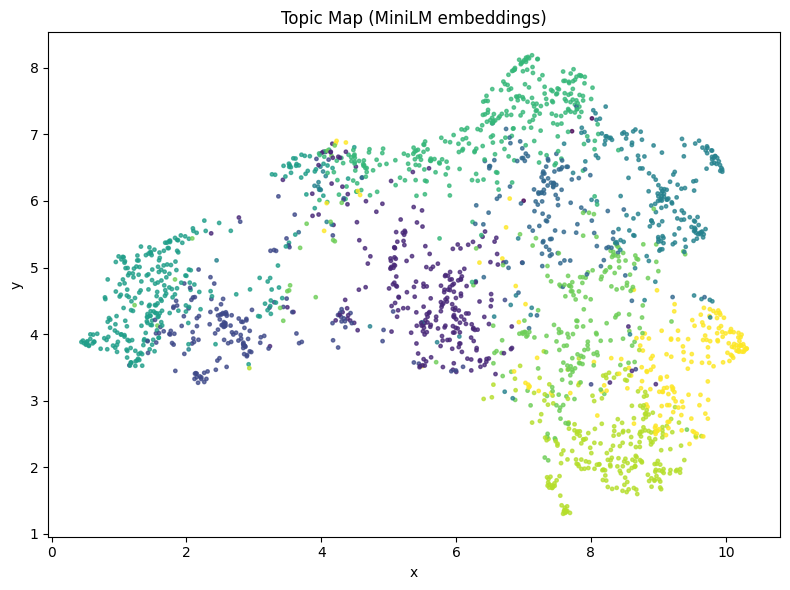

Saved plot: /data/UmdTask39_Fall2025_flash_attn_Topic_Modeling_of_Scientific_Papers/data/topic_map.png


In [8]:
import matplotlib.pyplot as plt

try:
    xy = reduce_2d(emb, method="umap")
except Exception as e:
    print("UMAP failed, using t-SNE:", e)
    xy = reduce_2d(emb, method="tsne")

df["x"], df["y"] = xy[:,0], xy[:,1]

plt.figure(figsize=(8,6))
plt.scatter(df["x"], df["y"], s=6, c=df["cluster"], alpha=0.75)
plt.title("Topic Map (MiniLM embeddings)")
plt.xlabel("x"); plt.ylabel("y")
plt.tight_layout()

PLOT_PATH = CLEAN_PATH.with_name("topic_map.png")
plt.savefig(PLOT_PATH, dpi=200)
plt.show()
print(f"Saved plot: {PLOT_PATH}")

In [3]:
# import checks
import sys, torch, sklearn, transformers, sentence_transformers, umap, pyarrow
print("Python:", sys.version.split()[0])
print("torch:", torch.__version__, "cuda:", torch.cuda.is_available())
print("sklearn:", sklearn.__version__)
print("transformers:", transformers.__version__)
print("sentence-transformers:", sentence_transformers.__version__)
print("umap OK; pyarrow:", pyarrow.__version__)


Python: 3.10.19
torch: 2.3.0 cuda: False
sklearn: 1.3.2
transformers: 4.44.2
sentence-transformers: 3.1.1
umap OK; pyarrow: 12.0.1
